# Notebook base: detección de personas con cámara

Este cuaderno implementa detección de personas con webcam utilizando YOLOv8 y registra métricas operativas en tiempo real.

**Contenido principal**
- detección de la clase persona
- visualización de cajas
- FPS
- tiempo de inferencia
- cantidad de personas por frame
- confianza promedio por frame
- exportación de métricas a CSV


In [1]:
# ==========================================================
# CELDA 1: Instalación sugerida dentro de Jupyter
# Ejecutar solo en caso necesario
# ==========================================================

# !pip install ultralytics opencv-python pandas numpy matplotlib


In [1]:
# ==========================================================
# CELDA 2: Importación de librerías y configuración inicial
# Entorno orientado a detección de personas con cámara
# ==========================================================

import cv2
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from ultralytics import YOLO
from pathlib import Path


In [2]:
# ==========================================================
# CELDA 3: Parámetros generales del sistema
# Clase objetivo: person
# ==========================================================

MODEL_NAME = "yolov8n.pt"
CAMERA_INDEX = 0
CONF_THRESHOLD = 0.40
IOU_THRESHOLD = 0.45
FRAME_WIDTH = 960
FRAME_HEIGHT = 540
WINDOW_NAME = "Deteccion de Personas - YOLOv8"
CSV_OUTPUT = "metricas_deteccion_personas.csv"
PERSON_CLASS_ID = 0


In [3]:
# ==========================================================
# CELDA 4: Estructuras para almacenamiento de métricas
# Registro por frame y métricas acumuladas
# ==========================================================

metricas_por_frame = []

fps_hist = deque(maxlen=30)
inferencia_hist = deque(maxlen=30)
conf_hist = []

total_frames = 0
total_detecciones = 0
inicio_global = time.time()


In [4]:
# ==========================================================
# CELDA 5: Funciones auxiliares para métricas y visualización
# Cálculo de estadísticas y anotación sobre frames
# ==========================================================

def calcular_resumen(metricas_df):
    if metricas_df.empty:
        return {
            "frames_procesados": 0,
            "detecciones_totales": 0,
            "fps_promedio": 0.0,
            "tiempo_inferencia_promedio_ms": 0.0,
            "personas_promedio_por_frame": 0.0,
            "confianza_promedio": 0.0,
            "confianza_minima": 0.0,
            "confianza_maxima": 0.0
        }

    confianza_validas = metricas_df["confianza_promedio_frame"].dropna()

    return {
        "frames_procesados": int(len(metricas_df)),
        "detecciones_totales": int(metricas_df["cantidad_personas"].sum()),
        "fps_promedio": float(metricas_df["fps"].mean()),
        "tiempo_inferencia_promedio_ms": float(metricas_df["tiempo_inferencia_ms"].mean()),
        "personas_promedio_por_frame": float(metricas_df["cantidad_personas"].mean()),
        "confianza_promedio": float(confianza_validas.mean()) if not confianza_validas.empty else 0.0,
        "confianza_minima": float(confianza_validas.min()) if not confianza_validas.empty else 0.0,
        "confianza_maxima": float(confianza_validas.max()) if not confianza_validas.empty else 0.0
    }


def dibujar_caja(frame, x1, y1, x2, y2, texto, color=(0, 255, 0), grosor=2):
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, grosor)
    cv2.putText(
        frame,
        texto,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2
    )


def dibujar_panel_metricas(frame, fps_actual, tiempo_inf_ms, cantidad_personas, confianza_promedio_frame):
    panel_textos = [
        f"FPS: {fps_actual:.2f}",
        f"Inferencia: {tiempo_inf_ms:.2f} ms",
        f"Personas: {cantidad_personas}",
        f"Confianza promedio: {confianza_promedio_frame:.2f}" if not math.isnan(confianza_promedio_frame) else "Confianza promedio: N/A"
    ]

    y = 30
    for texto in panel_textos:
        cv2.putText(
            frame,
            texto,
            (20, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 255),
            2
        )
        y += 30


In [5]:
# ==========================================================
# CELDA 6: Carga del modelo YOLOv8
# Descarga automática del peso en la primera ejecución
# ==========================================================

modelo = YOLO(MODEL_NAME)
print(f"Modelo cargado correctamente: {MODEL_NAME}")


Modelo cargado correctamente: yolov8n.pt


In [7]:
# ==========================================================
# CELDA 7: Inicialización de la cámara
# Ajuste básico de resolución
# ==========================================================

cap = cv2.VideoCapture(CAMERA_INDEX)

cap.set(cv2.CAP_PROP_FRAME_WIDTH, FRAME_WIDTH)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, FRAME_HEIGHT)

if not cap.isOpened():q
    raise RuntimeError("No fue posible acceder a la cámara.")

print("Cámara inicializada correctamente.")
print("Tecla Q: finalizar captura")


Cámara inicializada correctamente.
Tecla Q: finalizar captura


In [8]:
# ==========================================================
# CELDA 8: Detección en tiempo real con cálculo de métricas
# Filtrado exclusivo para la clase persona
# ==========================================================

while True:
    tiempo_frame_inicio = time.time()
    ret, frame = cap.read()

    if not ret:
        print("No fue posible leer un frame desde la cámara.")
        break

    inicio_inferencia = time.time()
    resultados = modelo.predict(
        source=frame,
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        verbose=False
    )
    fin_inferencia = time.time()

    tiempo_inferencia_ms = (fin_inferencia - inicio_inferencia) * 1000.0

    cantidad_personas = 0
    confianzas_frame = []

    if len(resultados) > 0:
        resultado = resultados[0]

        if resultado.boxes is not None and len(resultado.boxes) > 0:
            for box in resultado.boxes:
                clase = int(box.cls[0].item())
                confianza = float(box.conf[0].item())

                if clase == PERSON_CLASS_ID:
                    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                    cantidad_personas += 1
                    confianzas_frame.append(confianza)

                    etiqueta = f"Persona {confianza:.2f}"
                    dibujar_caja(frame, x1, y1, x2, y2, etiqueta)

    tiempo_frame_fin = time.time()
    tiempo_total_frame = tiempo_frame_fin - tiempo_frame_inicio
    fps_actual = 1.0 / tiempo_total_frame if tiempo_total_frame > 0 else 0.0

    confianza_promedio_frame = float(np.mean(confianzas_frame)) if len(confianzas_frame) > 0 else float("nan")

    fps_hist.append(fps_actual)
    inferencia_hist.append(tiempo_inferencia_ms)

    if len(confianzas_frame) > 0:
        conf_hist.extend(confianzas_frame)

    total_frames += 1
    total_detecciones += cantidad_personas

    metricas_por_frame.append({
        "frame_id": total_frames,
        "timestamp_seg": round(time.time() - inicio_global, 3),
        "fps": round(fps_actual, 4),
        "tiempo_inferencia_ms": round(tiempo_inferencia_ms, 4),
        "cantidad_personas": int(cantidad_personas),
        "confianza_promedio_frame": round(confianza_promedio_frame, 4) if not math.isnan(confianza_promedio_frame) else np.nan
    })

    dibujar_panel_metricas(
        frame,
        fps_actual=fps_actual,
        tiempo_inf_ms=tiempo_inferencia_ms,
        cantidad_personas=cantidad_personas,
        confianza_promedio_frame=confianza_promedio_frame
    )

    cv2.imshow(WINDOW_NAME, frame)

    tecla = cv2.waitKey(1) & 0xFF
    if tecla == ord("q"):
        break


In [9]:
# ==========================================================
# CELDA 9: Liberación de recursos
# Cierre de cámara y ventanas de OpenCV
# ==========================================================

cap.release()
cv2.destroyAllWindows()

print("Captura finalizada correctamente.")


Captura finalizada correctamente.


In [10]:
# ==========================================================
# CELDA 10: Construcción del DataFrame y guardado en CSV
# Registro histórico de métricas por frame
# ==========================================================

df_metricas = pd.DataFrame(metricas_por_frame)
df_metricas.to_csv(CSV_OUTPUT, index=False, encoding="utf-8")

print("Archivo CSV generado correctamente.")
print(f"Ruta de salida: {Path(CSV_OUTPUT).resolve()}")
display(df_metricas.head())


Archivo CSV generado correctamente.
Ruta de salida: /Users/dev/Downloads/BASESDEDATOS2/laboratorio18abrilsegundo/metricas_deteccion_personas.csv


,frame_id,timestamp_seg,fps,tiempo_inferencia_ms,cantidad_personas,confianza_promedio_frame
0,1,77.317,7.5939,109.7031,1,0.8675
1,2,77.444,32.8352,26.1111,1,0.8600
2,3,77.510,32.2208,23.9139,1,0.8575
3,4,77.583,17.9285,26.3162,1,0.8683
4,5,77.647,19.7452,25.6891,1,0.8754


In [11]:
# ==========================================================
# CELDA 11: Resumen general de métricas
# Estadísticas finales de la sesión de detección
# ==========================================================

resumen = calcular_resumen(df_metricas)

print("\n========== RESUMEN FINAL ==========")
for clave, valor in resumen.items():
    if isinstance(valor, float):
        print(f"{clave}: {valor:.4f}")
    else:
        print(f"{clave}: {valor}")



========== RESUMEN FINAL ==========
frames_procesados: 5162
detecciones_totales: 15126
fps_promedio: 19.2831
tiempo_inferencia_promedio_ms: 26.1881
personas_promedio_por_frame: 2.9303
confianza_promedio: 0.7718
confianza_minima: 0.5251
confianza_maxima: 0.9590


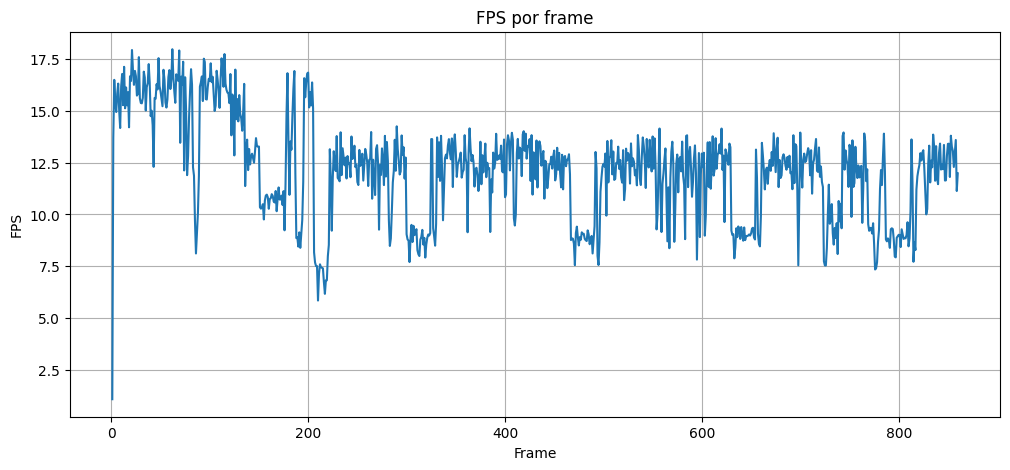

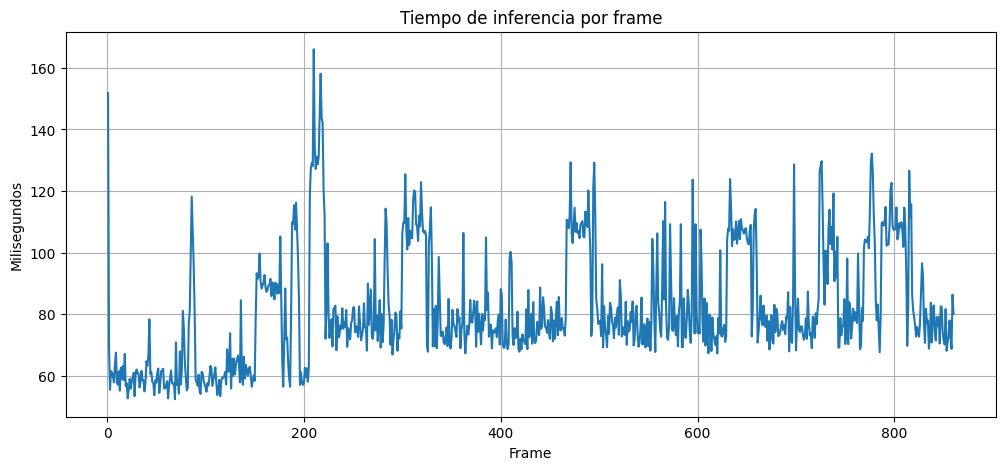

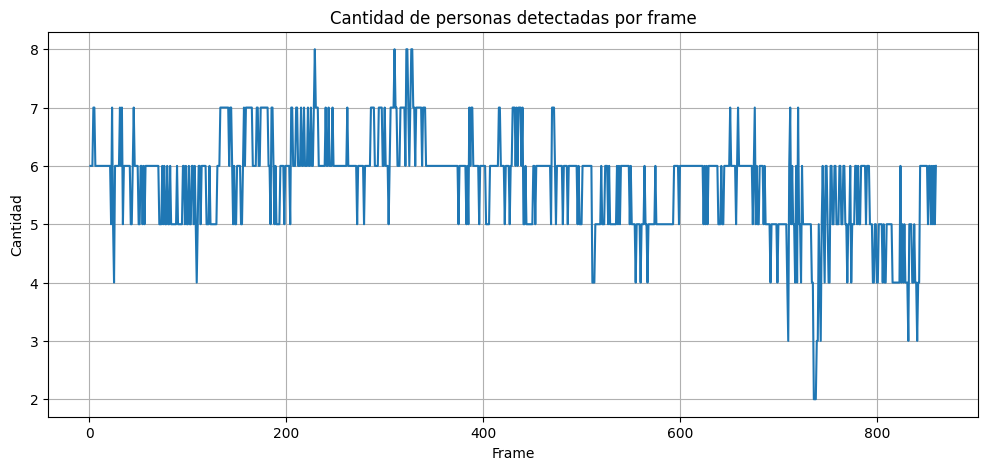

In [12]:
# ==========================================================
# CELDA 12: Visualización rápida de métricas
# Curvas de FPS, inferencia y cantidad de personas
# ==========================================================

if not df_metricas.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(df_metricas["frame_id"], df_metricas["fps"])
    plt.title("FPS por frame")
    plt.xlabel("Frame")
    plt.ylabel("FPS")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(df_metricas["frame_id"], df_metricas["tiempo_inferencia_ms"])
    plt.title("Tiempo de inferencia por frame")
    plt.xlabel("Frame")
    plt.ylabel("Milisegundos")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(df_metricas["frame_id"], df_metricas["cantidad_personas"])
    plt.title("Cantidad de personas detectadas por frame")
    plt.xlabel("Frame")
    plt.ylabel("Cantidad")
    plt.grid(True)
    plt.show()
else:
    print("Sin datos para visualización.")
